# Eigenvalue Comparison: K-FAC vs EK-FAC

Compare eigenvalues computed from covariance matrices (K-FAC approximation: λ_G ⊗ λ_A)
vs eigenvalue corrections (EK-FAC: actual diagonal in eigenbasis).

This helps understand why EK-FAC selects more pairs for the same mass ratio.

In [1]:
%matplotlib ipympl

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from safetensors import safe_open

plt.rcParams['figure.figsize'] = (12, 8)

/home/smarter/opt/bergson/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
# Path to bergson factors
BERGSON_PATH = Path("../data/kfac_factors_paper_bergson/olmo2_7b/influence_results")

def load_sharded(path: Path) -> dict:
    """Load sharded safetensors, concatenating along dim=0."""
    shard_files = sorted(path.glob("shard_*.safetensors"))
    if len(shard_files) == 1:
        with safe_open(shard_files[0], framework="pt", device="cpu") as f:
            return {key: f.get_tensor(key) for key in f.keys()}
    
    with safe_open(shard_files[0], framework="pt", device="cpu") as f:
        keys = list(f.keys())
    
    result = {}
    for key in keys:
        shards = []
        for shard_file in shard_files:
            with safe_open(shard_file, framework="pt", device="cpu") as f:
                shards.append(f.get_tensor(key))
        result[key] = torch.cat(shards, dim=0)
    return result

In [4]:
# Load all data
print("Loading covariances...")
act_cov = load_sharded(BERGSON_PATH / "activation_covariance_sharded")
grad_cov = load_sharded(BERGSON_PATH / "gradient_covariance_sharded")

print("Loading eigenvectors...")
act_eigen = load_sharded(BERGSON_PATH / "activation_eigen_sharded")
grad_eigen = load_sharded(BERGSON_PATH / "gradient_eigen_sharded")

print("Loading eigenvalue corrections...")
lambda_corr = load_sharded(BERGSON_PATH / "eigenvalue_correction_sharded")

total_processed_cov = torch.load(BERGSON_PATH / "total_processed_covariances.pt", map_location="cpu").item()
total_processed_lambda = torch.load(BERGSON_PATH / "total_processed_lambda_correction.pt", map_location="cpu").item()
print(f"Total processed (covariances): {total_processed_cov:,}")
print(f"Total processed (lambda): {total_processed_lambda:,}")

print(f"\nAvailable layers: {list(act_cov.keys())}")

Loading covariances...
Loading eigenvectors...
Loading eigenvalue corrections...
Total processed (covariances): 21,783,930
Total processed (lambda): 21,783,930

Available layers: ['layers.23.mlp.down_proj', 'layers.23.mlp.gate_proj', 'layers.23.mlp.up_proj', 'layers.24.mlp.down_proj', 'layers.24.mlp.gate_proj', 'layers.24.mlp.up_proj', 'layers.25.mlp.down_proj', 'layers.25.mlp.gate_proj', 'layers.25.mlp.up_proj']


In [5]:
def compute_kfac_eigenvalues(layer_key: str):
    """
    Compute eigenvalues the K-FAC way: from covariance matrices.
    Returns λ_G, λ_A and the outer product λ_G ⊗ λ_A.
    """
    # Get eigenvectors
    evc_A = act_eigen[layer_key].float()
    evc_G = grad_eigen[layer_key].float()
    
    # Normalize and symmetrize covariances
    cov_A = act_cov[layer_key].float() / total_processed_cov
    cov_A = (cov_A + cov_A.T) / 2
    cov_G = grad_cov[layer_key].float() / total_processed_cov
    cov_G = (cov_G + cov_G.T) / 2
    
    # Compute eigenvalues: λ_i = v_i^T @ C @ v_i
    eva_A = (evc_A.T @ cov_A @ evc_A).diagonal()
    eva_G = (evc_G.T @ cov_G @ evc_G).diagonal()
    
    # Sort descending (bergson stores ascending from eigh)
    idx_A = eva_A.argsort(descending=True)
    idx_G = eva_G.argsort(descending=True)
    eva_A = eva_A[idx_A]
    eva_G = eva_G[idx_G]
    
    # K-FAC approximation: outer product
    kfac_matrix = eva_G.unsqueeze(1) * eva_A.unsqueeze(0)  # [G, A]
    
    return eva_G, eva_A, kfac_matrix, idx_G, idx_A


def get_ekfac_matrix(layer_key: str, idx_G, idx_A):
    """
    Get eigenvalue correction matrix, reordered to match descending eigenvalue order.
    Normalized by total_processed_lambda.
    """
    corr = lambda_corr[layer_key].float() / total_processed_lambda
    # Reorder to match descending eigenvalue order
    corr = corr[idx_G][:, idx_A]
    return corr

In [96]:
# Analyze a specific layer
layer_key = "layers.24.mlp.up_proj"

eva_G, eva_A, kfac_matrix, idx_G, idx_A = compute_kfac_eigenvalues(layer_key)
ekfac_matrix = get_ekfac_matrix(layer_key, idx_G, idx_A)

print(f"Layer: {layer_key}")
print(f"Shape: G={len(eva_G)}, A={len(eva_A)}")
print(f"K-FAC matrix shape: {kfac_matrix.shape}")
print(f"EK-FAC matrix shape: {ekfac_matrix.shape}")
print(f"\nK-FAC total mass: {kfac_matrix.sum().item():.6f}")
print(f"EK-FAC total mass: {ekfac_matrix.sum().item():.6f}")

Layer: layers.24.mlp.up_proj
Shape: G=11008, A=4096
K-FAC matrix shape: torch.Size([11008, 4096])
EK-FAC matrix shape: torch.Size([11008, 4096])

K-FAC total mass: 244.084656
EK-FAC total mass: 144.636597


In [32]:
print("eigA[0], eigA[-1] =", eva_A[0].item(), eva_A[-1].item())
print("argmax eigA =", torch.argmax(eva_A).item())

eigA[0], eigA[-1] = 97.69597625732422 0.026446973904967308
argmax eigA = 0


In [44]:
# flat index of max
flat_idx = torch.argmax(ekfac_matrix)  # scalar tensor
print(flat_idx)

# convert to (row, col)
row, col = torch.unravel_index(flat_idx, ekfac_matrix.shape)

print(row.item(), col.item())
print(ekfac_matrix[row, col].item())

tensor(4096)
1 0
0.013946707360446453


In [89]:
x = lambda_corr[layer_key].float() / total_processed_lambda #ekfac_matrix
k = 100

#torch.set_printoptions(threshold=100)

# 1) top-k on flattened tensor
vals, flat_idx = x.flatten().topk(k)

# 2) convert flat indices -> (row, col)
rows = flat_idx // x.size(1)
cols = flat_idx %  x.size(1)

# rows, cols are the indices; vals are the corresponding values
print(vals)          # top-k values
#idx2d = torch.stack((rows, cols), dim=1)
print(cols[cols < 4000]) 

tensor([0.0275, 0.0048, 0.0043, 0.0042, 0.0041, 0.0038, 0.0035, 0.0033, 0.0033,
        0.0032, 0.0031, 0.0031, 0.0031, 0.0026, 0.0025, 0.0024, 0.0024, 0.0023,
        0.0022, 0.0020, 0.0020, 0.0020, 0.0019, 0.0019, 0.0018, 0.0018, 0.0017,
        0.0017, 0.0016, 0.0016, 0.0015, 0.0015, 0.0015, 0.0015, 0.0014, 0.0014,
        0.0014, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0010, 0.0010,
        0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
        0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
        0.0010])
tensor([ 4, 12,  3,  4])


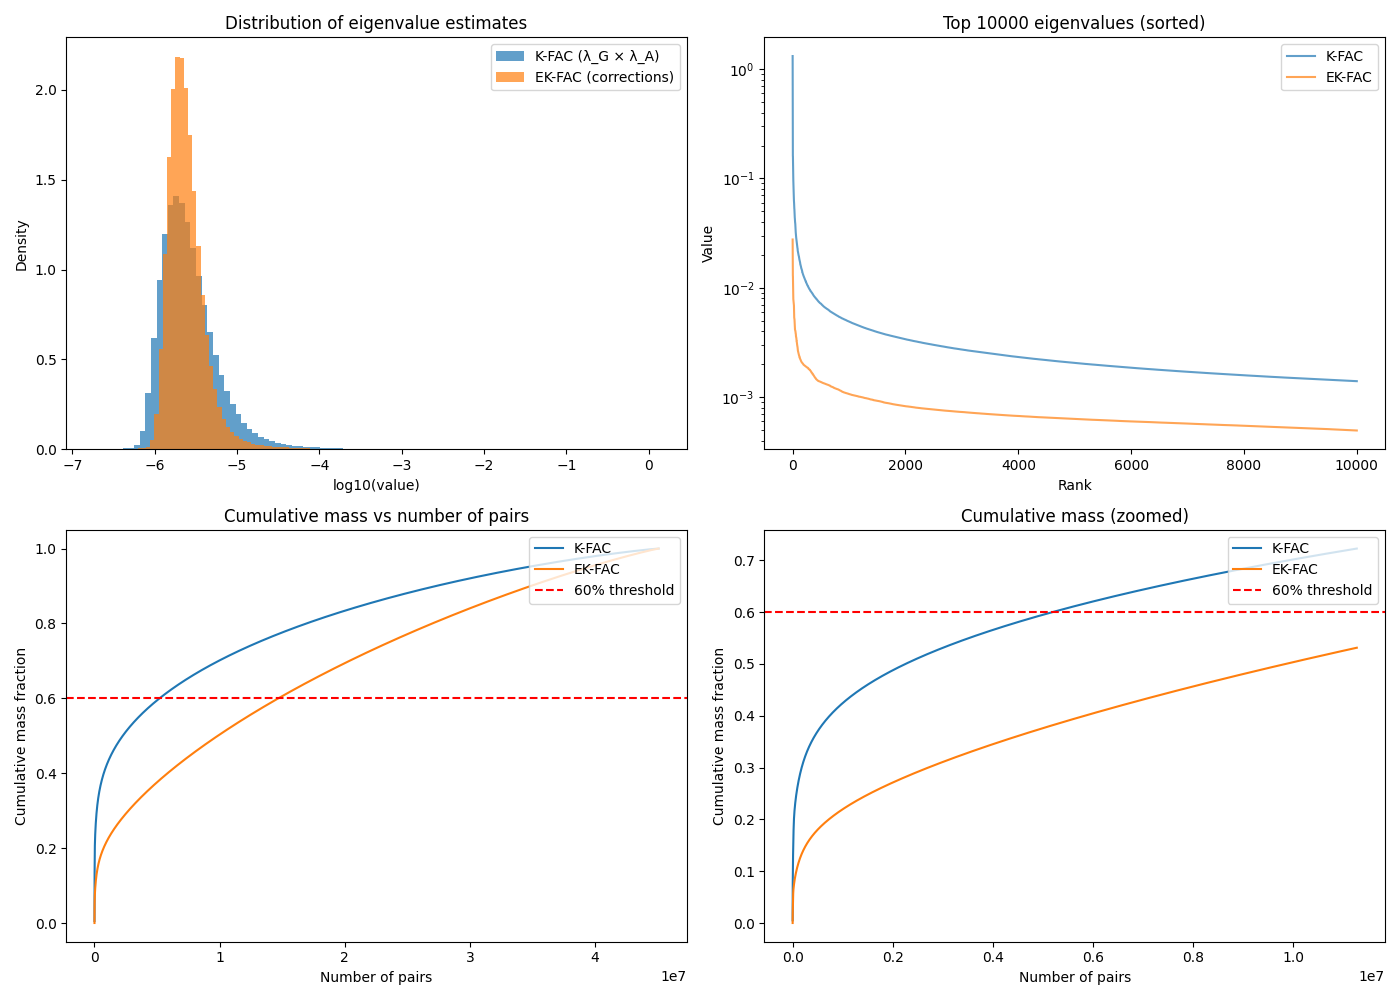

In [97]:
# Compare distributions of values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten for comparison (use float64 to avoid precision loss in cumsum)
kfac_flat = kfac_matrix.flatten().numpy().astype(np.float64)
ekfac_flat = ekfac_matrix.flatten().numpy().astype(np.float64)

# Histogram of values
ax = axes[0, 0]
ax.hist(np.log10(kfac_flat + 1e-12), bins=100, alpha=0.7, label='K-FAC (λ_G × λ_A)', density=True)
ax.hist(np.log10(ekfac_flat + 1e-12), bins=100, alpha=0.7, label='EK-FAC (corrections)', density=True)
ax.set_xlabel('log10(value)')
ax.set_ylabel('Density')
ax.set_title('Distribution of eigenvalue estimates')
ax.legend(loc='upper right')

# Sorted values comparison
ax = axes[0, 1]
kfac_sorted = np.sort(kfac_flat)[::-1]
ekfac_sorted = np.sort(ekfac_flat)[::-1]
n_show = 10000
ax.semilogy(kfac_sorted[:n_show], label='K-FAC', alpha=0.7)
ax.semilogy(ekfac_sorted[:n_show], label='EK-FAC', alpha=0.7)
ax.set_xlabel('Rank')
ax.set_ylabel('Value')
ax.set_title(f'Top {n_show} eigenvalues (sorted)')
ax.legend(loc='upper right')

# Cumulative mass
ax = axes[1, 0]
kfac_cumsum = np.cumsum(kfac_sorted) / kfac_sorted.sum()
ekfac_cumsum = np.cumsum(ekfac_sorted) / ekfac_sorted.sum()
ax.plot(kfac_cumsum, label='K-FAC')
ax.plot(ekfac_cumsum, label='EK-FAC')
ax.axhline(0.6, color='r', linestyle='--', label='60% threshold')
ax.set_xlabel('Number of pairs')
ax.set_ylabel('Cumulative mass fraction')
ax.set_title('Cumulative mass vs number of pairs')
ax.legend(loc='upper right')

# Zoomed cumulative mass
ax = axes[1, 1]
n_zoom = len(kfac_flat) // 4
ax.plot(kfac_cumsum[:n_zoom], label='K-FAC')
ax.plot(ekfac_cumsum[:n_zoom], label='EK-FAC')
ax.axhline(0.6, color='r', linestyle='--', label='60% threshold')
ax.set_xlabel('Number of pairs')
ax.set_ylabel('Cumulative mass fraction')
ax.set_title('Cumulative mass (zoomed)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [98]:
# Count pairs needed for different mass thresholds
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

print(f"{'Threshold':<12} {'K-FAC pairs':<15} {'EK-FAC pairs':<15} {'Ratio':<10}")
print("-" * 55)

for thresh in thresholds:
    kfac_k = np.searchsorted(kfac_cumsum, thresh) + 1
    ekfac_k = np.searchsorted(ekfac_cumsum, thresh) + 1
    ratio = ekfac_k / kfac_k if kfac_k > 0 else float('inf')
    total = len(kfac_flat)
    print(f"{thresh:<12.0%} {kfac_k:<15,} ({kfac_k/total:.1%})   {ekfac_k:<15,} ({ekfac_k/total:.1%})   {ratio:.2f}x")

Threshold    K-FAC pairs     EK-FAC pairs    Ratio     
-------------------------------------------------------
50%          2,256,146       (5.0%)   9,851,480       (21.8%)   4.37x
60%          5,195,417       (11.5%)   14,688,064      (32.6%)   2.83x
70%          9,917,120       (22.0%)   20,367,358      (45.2%)   2.05x
80%          16,940,603      (37.6%)   27,000,249      (59.9%)   1.59x
90%          27,288,410      (60.5%)   34,858,711      (77.3%)   1.28x
95%          34,495,054      (76.5%)   39,462,174      (87.5%)   1.14x


In [99]:
ekfac_cumsum[5195417]

0.3817695559374256

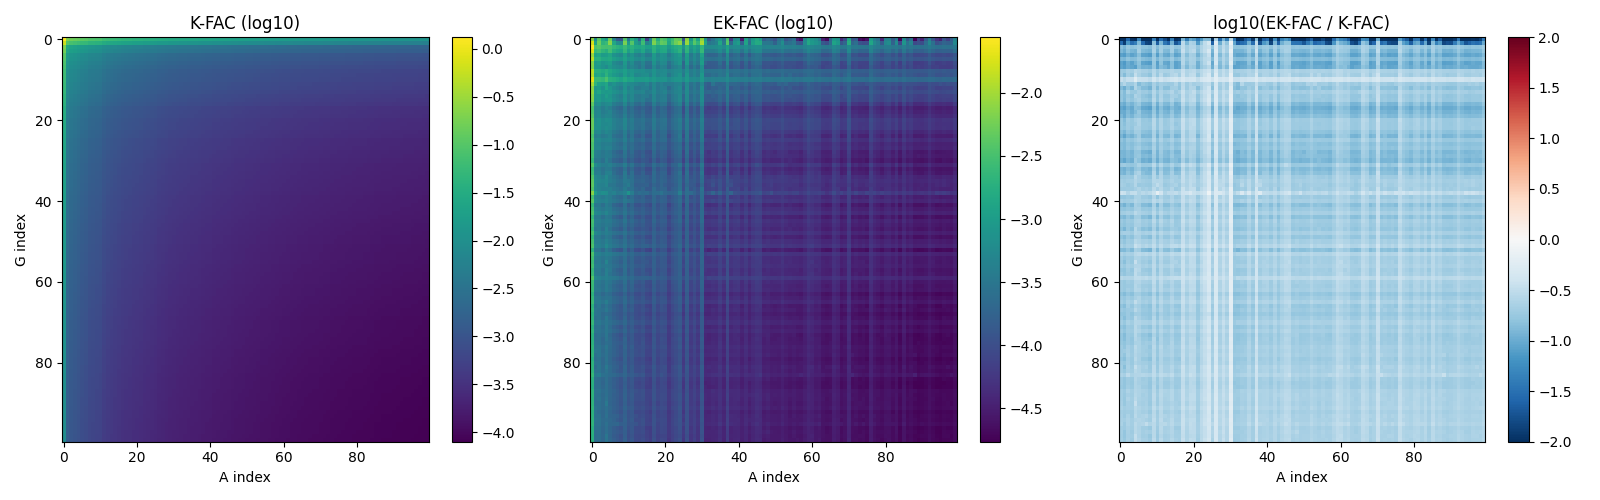

In [103]:
# Visualize the matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Show top-left corner
n_show = 100

ax = axes[0]
im = ax.imshow(np.log10(kfac_matrix[:n_show, :n_show].numpy() + 1e-12), aspect='auto', cmap='viridis')
ax.set_title('K-FAC (log10)')
ax.set_xlabel('A index')
ax.set_ylabel('G index')
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(np.log10(ekfac_matrix[:n_show, :n_show].numpy() + 1e-12), aspect='auto', cmap='viridis')
ax.set_title('EK-FAC (log10)')
ax.set_xlabel('A index')
ax.set_ylabel('G index')
plt.colorbar(im, ax=ax)

# Ratio
ax = axes[2]
ratio_matrix = ekfac_matrix[:n_show, :n_show] / (kfac_matrix[:n_show, :n_show] + 1e-12)
im = ax.imshow(np.log10(ratio_matrix.numpy() + 1e-12), aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_title('log10(EK-FAC / K-FAC)')
ax.set_xlabel('A index')
ax.set_ylabel('G index')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

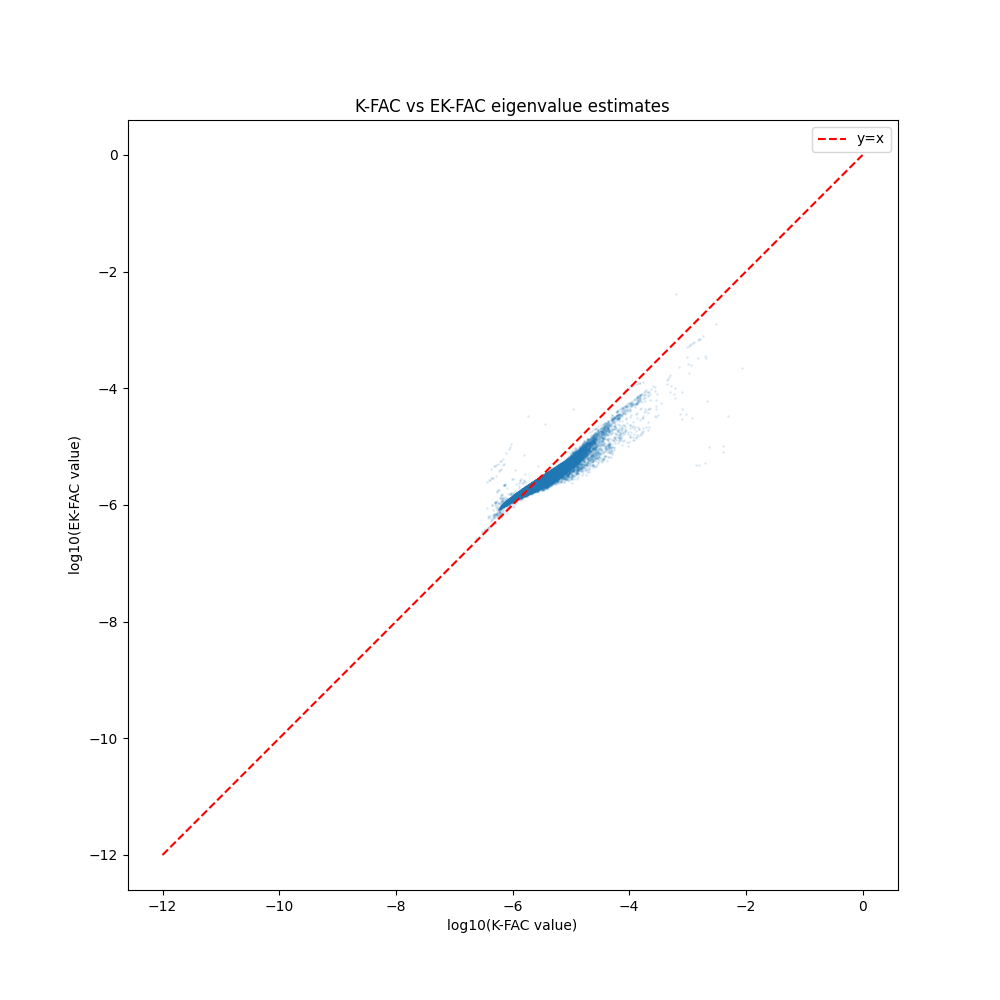

In [104]:
# Scatter plot: K-FAC vs EK-FAC values
fig, ax = plt.subplots(figsize=(10, 10))

# Sample for visualization
n_sample = 50000
indices = np.random.choice(len(kfac_flat), min(n_sample, len(kfac_flat)), replace=False)

ax.scatter(np.log10(kfac_flat[indices] + 1e-12), 
           np.log10(ekfac_flat[indices] + 1e-12), 
           alpha=0.1, s=1)
ax.plot([-12, 0], [-12, 0], 'r--', label='y=x')
ax.set_xlabel('log10(K-FAC value)')
ax.set_ylabel('log10(EK-FAC value)')
ax.set_title('K-FAC vs EK-FAC eigenvalue estimates')
ax.legend()
ax.set_aspect('equal')
plt.show()

In [101]:
# Analyze the structure of top pairs
def get_top_pairs(matrix, ratio):
   flat = matrix.flatten()
   sorted_vals, sorted_indices = torch.sort(flat, descending=True)
   # Use float64 for cumsum to avoid precision loss with millions of elements
   sorted_vals_f64 = sorted_vals.double()
   cumsum = torch.cumsum(sorted_vals_f64, dim=0)
   target = ratio * cumsum[-1]
   k = (cumsum >= target).nonzero()[0].item() + 1

   n = matrix.shape[1]
   selected = sorted_indices[:k]
   rows = (selected // n).numpy()
   cols = (selected % n).numpy()
   return rows, cols, k

ratio = 0.2
kfac_rows, kfac_cols, kfac_k = get_top_pairs(kfac_matrix, ratio)
ekfac_rows, ekfac_cols, ekfac_k = get_top_pairs(ekfac_matrix, ratio)

print(f"For {ratio:.0%} mass:")
print(f"  K-FAC:  {kfac_k:,} pairs")
print(f"  EK-FAC: {ekfac_k:,} pairs")
print(f"  Ratio:  {ekfac_k/kfac_k:.2f}x")

For 20% mass:
  K-FAC:  25,973 pairs
  EK-FAC: 722,143 pairs
  Ratio:  27.80x


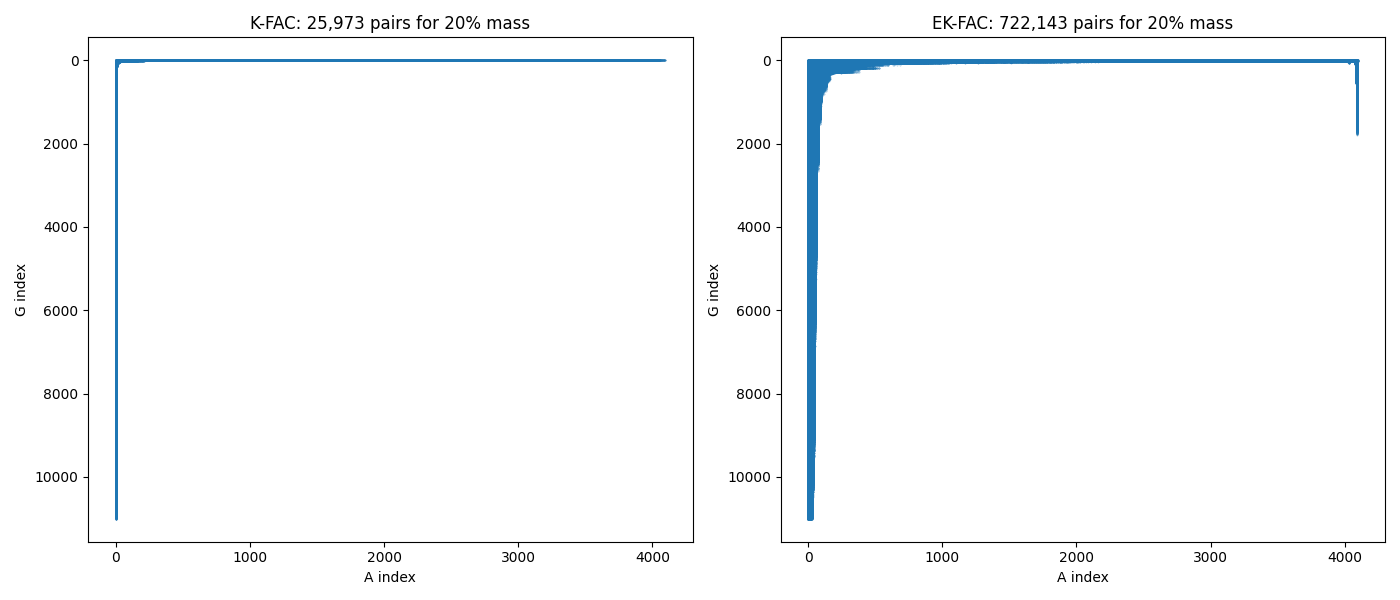

In [102]:
# Visualize which pairs are selected
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-FAC selection pattern
ax = axes[0]
ax.scatter(kfac_cols, kfac_rows, s=0.1, alpha=0.5)
ax.set_xlabel('A index')
ax.set_ylabel('G index')
ax.set_title(f'K-FAC: {kfac_k:,} pairs for {ratio:.0%} mass')
ax.invert_yaxis()

# EK-FAC selection pattern  
ax = axes[1]
ax.scatter(ekfac_cols, ekfac_rows, s=0.1, alpha=0.5)
ax.set_xlabel('A index')
ax.set_ylabel('G index')
ax.set_title(f'EK-FAC: {ekfac_k:,} pairs for {ratio:.0%} mass')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Analyze all layers
print(f"{'Layer':<35} {'K-FAC pairs':>12} {'EK-FAC pairs':>12} {'Ratio':>8}")
print("-" * 70)

for layer_key in sorted(act_cov.keys()):
    eva_G, eva_A, kfac_mat, idx_G, idx_A = compute_kfac_eigenvalues(layer_key)
    ekfac_mat = get_ekfac_matrix(layer_key, idx_G, idx_A)
    
    _, _, kfac_k = get_top_pairs(kfac_mat, 0.6)
    _, _, ekfac_k = get_top_pairs(ekfac_mat, 0.6)
    
    ratio = ekfac_k / kfac_k
    print(f"{layer_key:<35} {kfac_k:>12,} {ekfac_k:>12,} {ratio:>8.2f}x")

/tmp/ipykernel_223206/3200923123.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))


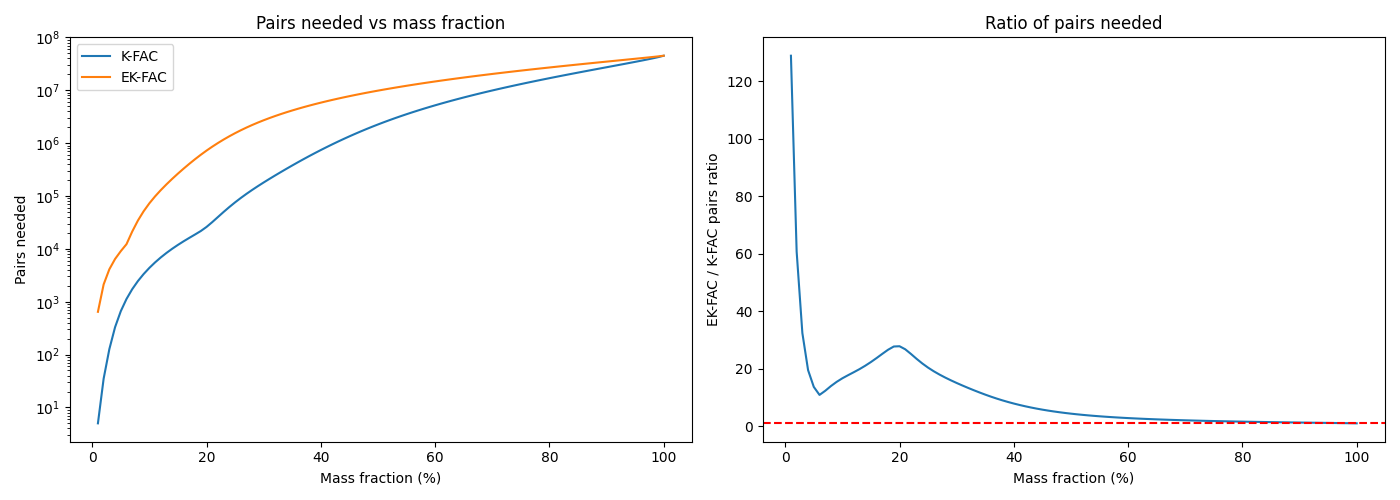

In [106]:
# Why does EK-FAC need more pairs? Let's look at the value distribution more closely
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Concentration of mass in top values
ax = axes[0]
fracs = np.arange(0.01, 1.01, 0.01)
kfac_pairs_needed = [np.searchsorted(kfac_cumsum, f) + 1 for f in fracs]
ekfac_pairs_needed = [np.searchsorted(ekfac_cumsum, f) + 1 for f in fracs]
ax.plot(fracs * 100, kfac_pairs_needed, label='K-FAC')
ax.plot(fracs * 100, ekfac_pairs_needed, label='EK-FAC')
ax.set_xlabel('Mass fraction (%)')
ax.set_ylabel('Pairs needed')
ax.set_title('Pairs needed vs mass fraction')
ax.legend()
ax.set_yscale('log')

# Ratio of pairs needed
ax = axes[1]
ratio_pairs = np.array(ekfac_pairs_needed) / np.array(kfac_pairs_needed)
ax.plot(fracs * 100, ratio_pairs)
ax.axhline(1, color='r', linestyle='--')
ax.set_xlabel('Mass fraction (%)')
ax.set_ylabel('EK-FAC / K-FAC pairs ratio')
ax.set_title('Ratio of pairs needed')

plt.tight_layout()
plt.show()

In [108]:
# Key insight: Gini coefficient (measure of concentration)
def gini(values):
    """Gini coefficient: 0 = perfectly equal, 1 = maximally concentrated"""
    sorted_vals = np.sort(values)
    n = len(sorted_vals)
    cumsum = np.cumsum(sorted_vals)
    return (2 * np.sum((np.arange(1, n+1) * sorted_vals)) / (n * cumsum[-1])) - (n + 1) / n

kfac_gini = gini(kfac_flat)
ekfac_gini = gini(ekfac_flat)

print(f"Gini coefficient (higher = more concentrated):")
print(f"  K-FAC:  {kfac_gini:.4f}")
print(f"  EK-FAC: {ekfac_gini:.4f}")
print(f"\nK-FAC is {kfac_gini/ekfac_gini:.2f}x more concentrated than EK-FAC")

Gini coefficient (higher = more concentrated):
  K-FAC:  0.6325
  EK-FAC: 0.3898

K-FAC is 1.62x more concentrated than EK-FAC
